# PUCT vs TTTS Model Exploration

Creative analysis of two Connect4 models trained with different MCTS algorithms.

**Beyond the Arena:** Instead of just playing games, we'll peer inside the models to understand *how* they think differently.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from collections import defaultdict

from nanozero.game import get_game
from nanozero.model import AlphaZeroTransformer
from nanozero.config import get_model_config

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
game = get_game('connect4')
print(f"Device: {device}")
print(f"Board: {game.config.board_height}x{game.config.board_width}")

Device: cpu
Board: 6x7


In [2]:
# Load both models
def load_model(path):
    state_dict = torch.load(path, map_location=device, weights_only=True)
    
    # Count transformer blocks to determine n_layer
    n_layer = max(int(k.split('.')[1]) for k in state_dict.keys() if k.startswith('blocks.')) + 1
    n_embd = state_dict['tok_emb.weight'].shape[1]
    
    print(f"Detected: n_layer={n_layer}, n_embd={n_embd}")
    
    # n_embd is auto-calculated as 64*n_layer, verify it matches
    config = get_model_config(game.config, n_layer=n_layer)
    assert config.n_embd == n_embd, f"n_embd mismatch: config={config.n_embd}, checkpoint={n_embd}"
    
    model = AlphaZeroTransformer(config).to(device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

puct_model = load_model('../checkpoints/puct_connect4_final.pt')
ttts_model = load_model('../checkpoints/ttts_connect4_final.pt')

print(f"\nParameters: {puct_model.count_parameters():,}")

Detected: n_layer=4, n_embd=256
Detected: n_layer=4, n_embd=256

Parameters: 3,175,488


## 1. Opening Personality

What move does each model prefer on an empty board? Do they have different "opening books"?

In [3]:
def get_policy_and_value(model, state):
    """Get raw policy (before MCTS) and value for a position."""
    canonical = game.canonical_state(state)
    state_tensor = game.to_tensor(canonical).unsqueeze(0).to(device)
    action_mask = torch.from_numpy(game.legal_actions_mask(state)).unsqueeze(0).to(device)
    
    with torch.no_grad():
        log_policy, value = model(state_tensor, action_mask)
        policy = log_policy.exp().squeeze().cpu().numpy()
        value = value.squeeze().item()
    
    return policy, value

# Compare opening moves
empty_board = game.initial_state()

puct_policy, puct_value = get_policy_and_value(puct_model, empty_board)
ttts_policy, ttts_value = get_policy_and_value(ttts_model, empty_board)

print("Opening Move Preferences (column probabilities):")
print(f"{'Column':<10} {'PUCT':<15} {'TTTS':<15} {'Diff':<10}")
print("-" * 50)
for col in range(7):
    diff = ttts_policy[col] - puct_policy[col]
    marker = "<<<" if abs(diff) > 0.1 else ""
    print(f"{col:<10} {puct_policy[col]:<15.3f} {ttts_policy[col]:<15.3f} {diff:+.3f} {marker}")

print(f"\nValue estimates: PUCT={puct_value:.3f}, TTTS={ttts_value:.3f}")

Opening Move Preferences (column probabilities):
Column     PUCT            TTTS            Diff      
--------------------------------------------------
0          0.133           0.121           -0.012 
1          0.005           0.128           +0.123 <<<
2          0.228           0.155           -0.073 
3          0.253           0.191           -0.062 
4          0.248           0.150           -0.098 
5          0.005           0.137           +0.131 <<<
6          0.128           0.117           -0.010 

Value estimates: PUCT=0.255, TTTS=0.182


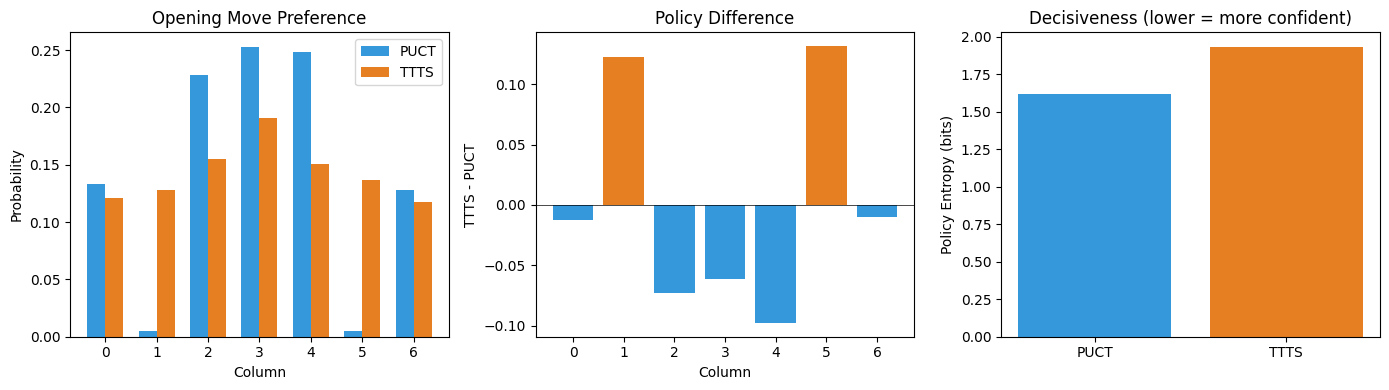

In [4]:
# Visualize opening preferences
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

cols = list(range(7))
width = 0.35

# Side by side
axes[0].bar([c - width/2 for c in cols], puct_policy, width, label='PUCT', color='#3498DB')
axes[0].bar([c + width/2 for c in cols], ttts_policy, width, label='TTTS', color='#E67E22')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('Probability')
axes[0].set_title('Opening Move Preference')
axes[0].legend()
axes[0].set_xticks(cols)

# Difference
diff = ttts_policy - puct_policy
colors = ['#E67E22' if d > 0 else '#3498DB' for d in diff]
axes[1].bar(cols, diff, color=colors)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_xlabel('Column')
axes[1].set_ylabel('TTTS - PUCT')
axes[1].set_title('Policy Difference')
axes[1].set_xticks(cols)

# Entropy comparison (how decisive?)
def entropy(p):
    p = p[p > 1e-8]
    return -np.sum(p * np.log(p))

puct_ent = entropy(puct_policy)
ttts_ent = entropy(ttts_policy)

axes[2].bar(['PUCT', 'TTTS'], [puct_ent, ttts_ent], color=['#3498DB', '#E67E22'])
axes[2].set_ylabel('Policy Entropy (bits)')
axes[2].set_title('Decisiveness (lower = more confident)')

plt.tight_layout()
plt.show()

## 2. Policy Disagreement Map

Let's play random games and find positions where the models disagree most strongly.

In [5]:
def policy_divergence(p1, p2):
    """KL divergence between two policies (symmetrized)."""
    p1 = np.clip(p1, 1e-8, 1)
    p2 = np.clip(p2, 1e-8, 1)
    kl1 = np.sum(p1 * np.log(p1 / p2))
    kl2 = np.sum(p2 * np.log(p2 / p1))
    return (kl1 + kl2) / 2

def collect_disagreements(n_games=100, max_moves=30):
    """Play random games and collect positions with policy disagreements."""
    disagreements = []
    
    for _ in range(n_games):
        state = game.initial_state()
        
        for move_num in range(max_moves):
            if game.is_terminal(state):
                break
            
            puct_p, puct_v = get_policy_and_value(puct_model, state)
            ttts_p, ttts_v = get_policy_and_value(ttts_model, state)
            
            div = policy_divergence(puct_p, ttts_p)
            value_diff = abs(puct_v - ttts_v)
            
            # What moves do they prefer?
            puct_move = np.argmax(puct_p)
            ttts_move = np.argmax(ttts_p)
            
            disagreements.append({
                'state': state.copy(),
                'move_num': move_num,
                'policy_div': div,
                'value_diff': value_diff,
                'puct_policy': puct_p,
                'ttts_policy': ttts_p,
                'puct_value': puct_v,
                'ttts_value': ttts_v,
                'puct_move': puct_move,
                'ttts_move': ttts_move,
                'move_disagree': puct_move != ttts_move
            })
            
            # Random move to continue game
            legal = game.legal_actions(state)
            action = np.random.choice(legal)
            state = game.next_state(state, action)
    
    return disagreements

print("Collecting positions from random games...")
disagreements = collect_disagreements(n_games=200)
print(f"Collected {len(disagreements)} positions")

Collected 4059 positions


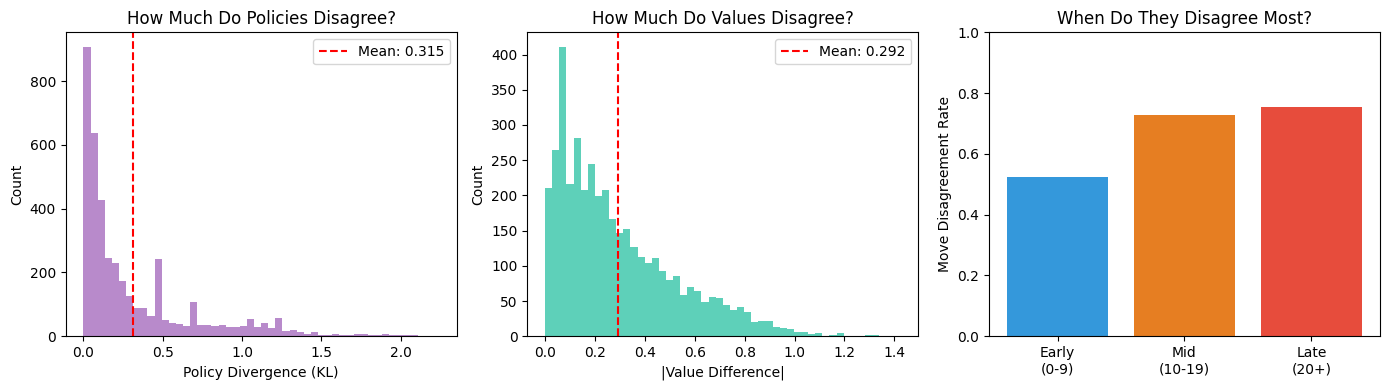


Overall move disagreement rate: 63.2%


In [6]:
# Analyze disagreement patterns
policy_divs = [d['policy_div'] for d in disagreements]
value_diffs = [d['value_diff'] for d in disagreements]
move_disagrees = [d['move_disagree'] for d in disagreements]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Policy divergence distribution
axes[0].hist(policy_divs, bins=50, color='#9B59B6', alpha=0.7)
axes[0].axvline(np.mean(policy_divs), color='red', linestyle='--', label=f'Mean: {np.mean(policy_divs):.3f}')
axes[0].set_xlabel('Policy Divergence (KL)')
axes[0].set_ylabel('Count')
axes[0].set_title('How Much Do Policies Disagree?')
axes[0].legend()

# Value difference distribution  
axes[1].hist(value_diffs, bins=50, color='#1ABC9C', alpha=0.7)
axes[1].axvline(np.mean(value_diffs), color='red', linestyle='--', label=f'Mean: {np.mean(value_diffs):.3f}')
axes[1].set_xlabel('|Value Difference|')
axes[1].set_ylabel('Count')
axes[1].set_title('How Much Do Values Disagree?')
axes[1].legend()

# Move disagreement by game phase
early = [d for d in disagreements if d['move_num'] < 10]
mid = [d for d in disagreements if 10 <= d['move_num'] < 20]
late = [d for d in disagreements if d['move_num'] >= 20]

phases = ['Early\n(0-9)', 'Mid\n(10-19)', 'Late\n(20+)']
disagree_rates = [
    np.mean([d['move_disagree'] for d in early]) if early else 0,
    np.mean([d['move_disagree'] for d in mid]) if mid else 0,
    np.mean([d['move_disagree'] for d in late]) if late else 0,
]

axes[2].bar(phases, disagree_rates, color=['#3498DB', '#E67E22', '#E74C3C'])
axes[2].set_ylabel('Move Disagreement Rate')
axes[2].set_title('When Do They Disagree Most?')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"\nOverall move disagreement rate: {np.mean(move_disagrees):.1%}")

Positions where models choose different moves: 2565

Top 6 disagreements:



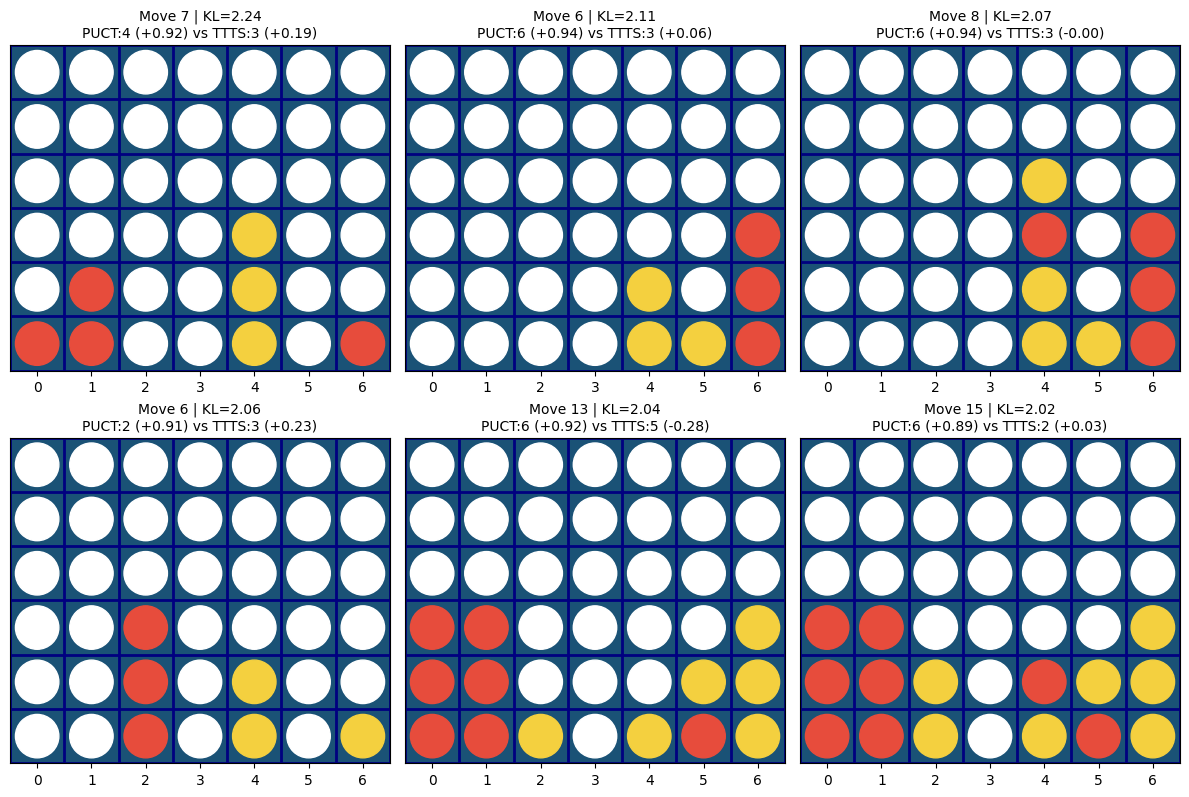

In [7]:
# Show top disagreement positions
def render_board_matplotlib(state, ax, title='', puct_move=None, ttts_move=None):
    """Render a Connect4 board with matplotlib."""
    ax.set_xlim(-0.5, 6.5)
    ax.set_ylim(-0.5, 5.5)
    
    # Draw grid
    for i in range(8):
        ax.axvline(i - 0.5, color='navy', linewidth=2)
    for i in range(7):
        ax.axhline(i - 0.5, color='navy', linewidth=2)
    
    ax.set_facecolor('#1a5276')
    
    # Draw pieces
    for row in range(6):
        for col in range(7):
            piece = state[5-row, col]  # Flip row for display
            if piece == 1:
                color = '#E74C3C'  # Red for player 1
            elif piece == -1:
                color = '#F4D03F'  # Yellow for player 2
            else:
                color = 'white'
            circle = plt.Circle((col, row), 0.4, color=color)
            ax.add_patch(circle)
    
    # Mark preferred moves
    if puct_move is not None:
        ax.annotate('P', (puct_move, 5.7), ha='center', fontsize=10, color='#3498DB', fontweight='bold')
    if ttts_move is not None:
        ax.annotate('T', (ttts_move, 5.7), ha='center', fontsize=10, color='#E67E22', fontweight='bold')
    
    ax.set_xticks(range(7))
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    ax.set_aspect('equal')

# Sort by policy divergence and show top disagreements
sorted_disagreements = sorted(disagreements, key=lambda x: x['policy_div'], reverse=True)

# Filter to positions where they pick different moves
move_disagreements = [d for d in sorted_disagreements if d['move_disagree']]

print(f"Positions where models choose different moves: {len(move_disagreements)}")
print("\nTop 6 disagreements:\n")

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, d in enumerate(move_disagreements[:6]):
    title = f"Move {d['move_num']} | KL={d['policy_div']:.2f}\nPUCT:{d['puct_move']} ({d['puct_value']:+.2f}) vs TTTS:{d['ttts_move']} ({d['ttts_value']:+.2f})"
    render_board_matplotlib(d['state'], axes[idx], title, d['puct_move'], d['ttts_move'])

plt.tight_layout()
plt.show()

### Deep Dive: Analyzing Top Disagreements

For each major disagreement, let's examine:
1. Current position policy and value for both models
2. Value of the resulting position after each legal move
3. Why might one model prefer a different move?

In [ ]:
def deep_analyze_position(state, title=""):
    """
    Deep analysis of a position showing:
    - Current policy and value for both models
    - Value after each legal action
    """
    legal_actions = game.legal_actions(state)
    
    # Get current position evaluation
    puct_policy, puct_value = get_policy_and_value(puct_model, state)
    ttts_policy, ttts_value = get_policy_and_value(ttts_model, state)
    
    # Get value after each action
    puct_next_values = {}
    ttts_next_values = {}
    
    for action in legal_actions:
        next_state = game.next_state(state, action)
        
        if game.is_terminal(next_state):
            # Terminal state - get actual reward (from perspective of player who just moved)
            reward = game.terminal_reward(next_state)
            # Flip sign because terminal_reward is from current player's view (opponent)
            puct_next_values[action] = -reward
            ttts_next_values[action] = -reward
        else:
            # Non-terminal - get model's value (from opponent's perspective, so flip)
            _, pv = get_policy_and_value(puct_model, next_state)
            _, tv = get_policy_and_value(ttts_model, next_state)
            puct_next_values[action] = -pv  # Flip because it's opponent's turn
            ttts_next_values[action] = -tv
    
    # Create visualization
    fig = plt.figure(figsize=(16, 10))
    
    # Layout: board on left, analysis on right
    gs = fig.add_gridspec(3, 3, width_ratios=[1.2, 1, 1], height_ratios=[1, 1, 0.8])
    
    # Board visualization
    ax_board = fig.add_subplot(gs[:2, 0])
    render_board_matplotlib(state, ax_board, title)
    
    # Current position values
    ax_values = fig.add_subplot(gs[0, 1:])
    ax_values.axis('off')
    
    current_player = game.current_player(state)
    player_str = "Red (1)" if current_player == 1 else "Yellow (-1)"
    
    info_text = f"Current Player: {player_str}\n\n"
    info_text += f"Position Value:\n"
    info_text += f"  PUCT:  {puct_value:+.3f}\n"
    info_text += f"  TTTS:  {ttts_value:+.3f}\n"
    info_text += f"  Diff:  {ttts_value - puct_value:+.3f}\n\n"
    
    puct_best = np.argmax(puct_policy)
    ttts_best = np.argmax(ttts_policy)
    info_text += f"Preferred Move:\n"
    info_text += f"  PUCT:  column {puct_best} (prob={puct_policy[puct_best]:.3f})\n"
    info_text += f"  TTTS:  column {ttts_best} (prob={ttts_policy[ttts_best]:.3f})\n"
    
    ax_values.text(0.1, 0.9, info_text, transform=ax_values.transAxes, 
                   fontsize=11, verticalalignment='top', fontfamily='monospace',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Policy comparison bar chart
    ax_policy = fig.add_subplot(gs[1, 1])
    x = np.arange(7)
    width = 0.35
    ax_policy.bar(x - width/2, puct_policy, width, label='PUCT', color='#3498DB', alpha=0.8)
    ax_policy.bar(x + width/2, ttts_policy, width, label='TTTS', color='#E67E22', alpha=0.8)
    ax_policy.set_xlabel('Column')
    ax_policy.set_ylabel('Policy Probability')
    ax_policy.set_title('Policy Distribution')
    ax_policy.set_xticks(x)
    ax_policy.legend()
    ax_policy.set_ylim(0, 1)
    
    # Highlight the disagreement
    if puct_best != ttts_best:
        ax_policy.axvline(puct_best, color='#3498DB', linestyle='--', alpha=0.5)
        ax_policy.axvline(ttts_best, color='#E67E22', linestyle='--', alpha=0.5)
    
    # Value after each move
    ax_next = fig.add_subplot(gs[1, 2])
    
    puct_vals = [puct_next_values.get(a, 0) for a in range(7)]
    ttts_vals = [ttts_next_values.get(a, 0) for a in range(7)]
    
    # Gray out illegal moves
    for a in range(7):
        if a not in legal_actions:
            puct_vals[a] = np.nan
            ttts_vals[a] = np.nan
    
    ax_next.bar(x - width/2, puct_vals, width, label='PUCT', color='#3498DB', alpha=0.8)
    ax_next.bar(x + width/2, ttts_vals, width, label='TTTS', color='#E67E22', alpha=0.8)
    ax_next.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax_next.set_xlabel('Column')
    ax_next.set_ylabel('Value After Move')
    ax_next.set_title('Expected Value After Each Action')
    ax_next.set_xticks(x)
    ax_next.legend()
    ax_next.set_ylim(-1.1, 1.1)
    
    # Highlight best moves
    if puct_best != ttts_best:
        ax_next.axvline(puct_best, color='#3498DB', linestyle='--', alpha=0.5)
        ax_next.axvline(ttts_best, color='#E67E22', linestyle='--', alpha=0.5)
    
    # Table of values
    ax_table = fig.add_subplot(gs[2, :])
    ax_table.axis('off')
    
    table_data = []
    headers = ['Column', 'Legal', 'PUCT Policy', 'TTTS Policy', 'PUCT Next Val', 'TTTS Next Val', 'Notes']
    
    for col in range(7):
        legal = 'Yes' if col in legal_actions else 'No'
        puct_p = f"{puct_policy[col]:.3f}" if col in legal_actions else "-"
        ttts_p = f"{ttts_policy[col]:.3f}" if col in legal_actions else "-"
        puct_nv = f"{puct_next_values.get(col, 0):+.3f}" if col in legal_actions else "-"
        ttts_nv = f"{ttts_next_values.get(col, 0):+.3f}" if col in legal_actions else "-"
        
        notes = []
        if col == puct_best:
            notes.append("PUCT choice")
        if col == ttts_best:
            notes.append("TTTS choice")
        if col in legal_actions:
            if puct_next_values[col] > 0.9:
                notes.append("PUCT sees win!")
            elif puct_next_values[col] < -0.9:
                notes.append("PUCT sees loss")
            if ttts_next_values[col] > 0.9:
                notes.append("TTTS sees win!")
            elif ttts_next_values[col] < -0.9:
                notes.append("TTTS sees loss")
        
        table_data.append([col, legal, puct_p, ttts_p, puct_nv, ttts_nv, ", ".join(notes)])
    
    table = ax_table.table(cellText=table_data, colLabels=headers, 
                           loc='center', cellLoc='center',
                           colColours=['lightgray']*7)
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
    
    # Color the choice rows
    for i, col in enumerate(range(7)):
        if col == puct_best:
            table[(i+1, 0)].set_facecolor('#D6EAF8')
            table[(i+1, 2)].set_facecolor('#D6EAF8')
            table[(i+1, 4)].set_facecolor('#D6EAF8')
        if col == ttts_best:
            table[(i+1, 0)].set_facecolor('#FDEBD0')
            table[(i+1, 3)].set_facecolor('#FDEBD0')
            table[(i+1, 5)].set_facecolor('#FDEBD0')
    
    plt.tight_layout()
    plt.show()
    
    # Return analysis summary
    return {
        'puct_value': puct_value,
        'ttts_value': ttts_value,
        'puct_best': puct_best,
        'ttts_best': ttts_best,
        'puct_next_values': puct_next_values,
        'ttts_next_values': ttts_next_values
    }


# Analyze top 5 disagreements
print("="*70)
print("DEEP ANALYSIS OF TOP DISAGREEMENTS")
print("="*70)

for i, d in enumerate(move_disagreements[:5]):
    print(f"\n{'='*70}")
    print(f"DISAGREEMENT #{i+1} (Move {d['move_num']}, KL divergence: {d['policy_div']:.3f})")
    print("="*70)
    
    analysis = deep_analyze_position(
        d['state'], 
        f"Disagreement #{i+1}: PUCT plays {d['puct_move']}, TTTS plays {d['ttts_move']}"
    )
    
    # Print interpretation
    print("\nInterpretation:")
    puct_best_val = analysis['puct_next_values'][analysis['puct_best']]
    ttts_best_val = analysis['ttts_next_values'][analysis['ttts_best']]
    puct_sees_ttts = analysis['puct_next_values'][analysis['ttts_best']]
    ttts_sees_puct = analysis['ttts_next_values'][analysis['puct_best']]
    
    print(f"  PUCT plays col {analysis['puct_best']}: expects value {puct_best_val:+.3f}")
    print(f"  TTTS plays col {analysis['ttts_best']}: expects value {ttts_best_val:+.3f}")
    print(f"  PUCT's view of TTTS's move (col {analysis['ttts_best']}): {puct_sees_ttts:+.3f}")
    print(f"  TTTS's view of PUCT's move (col {analysis['puct_best']}): {ttts_sees_puct:+.3f}")
    
    if abs(puct_best_val - ttts_sees_puct) > 0.3:
        print(f"  -> Models strongly disagree on value of PUCT's choice!")
    if abs(ttts_best_val - puct_sees_ttts) > 0.3:
        print(f"  -> Models strongly disagree on value of TTTS's choice!")

## 3. Attention Pattern Analysis

Where do the transformers "look" when evaluating positions? We'll hook into the attention layers.

In [8]:
class AttentionExtractor:
    """Hook to extract attention weights from transformer."""
    
    def __init__(self, model):
        self.model = model
        self.attentions = []
        self.hooks = []
        
    def _hook_fn(self, module, input, output):
        # Extract Q, K from the qkv projection
        x = input[0]
        B, T, C = x.shape
        qkv = module.qkv(x)
        q, k, v = qkv.split(module.n_embd, dim=-1)
        
        q = q.view(B, T, module.n_head, module.head_dim).transpose(1, 2)
        k = k.view(B, T, module.n_head, module.head_dim).transpose(1, 2)
        
        # Compute attention weights
        scale = 1.0 / (module.head_dim ** 0.5)
        attn = torch.matmul(q, k.transpose(-2, -1)) * scale
        attn = F.softmax(attn, dim=-1)
        
        self.attentions.append(attn.detach().cpu())
    
    def register_hooks(self):
        for block in self.model.blocks:
            hook = block.attn.register_forward_hook(self._hook_fn)
            self.hooks.append(hook)
    
    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()
        self.hooks = []
    
    def clear(self):
        self.attentions = []
    
    def get_attention(self, state):
        """Get attention weights for a position."""
        self.clear()
        canonical = game.canonical_state(state)
        state_tensor = game.to_tensor(canonical).unsqueeze(0).to(device)
        action_mask = torch.from_numpy(game.legal_actions_mask(state)).unsqueeze(0).to(device)
        
        with torch.no_grad():
            _ = self.model(state_tensor, action_mask)
        
        return self.attentions

puct_extractor = AttentionExtractor(puct_model)
puct_extractor.register_hooks()

ttts_extractor = AttentionExtractor(ttts_model)
ttts_extractor.register_hooks()

print("Attention extractors ready!")

Attention extractors ready!


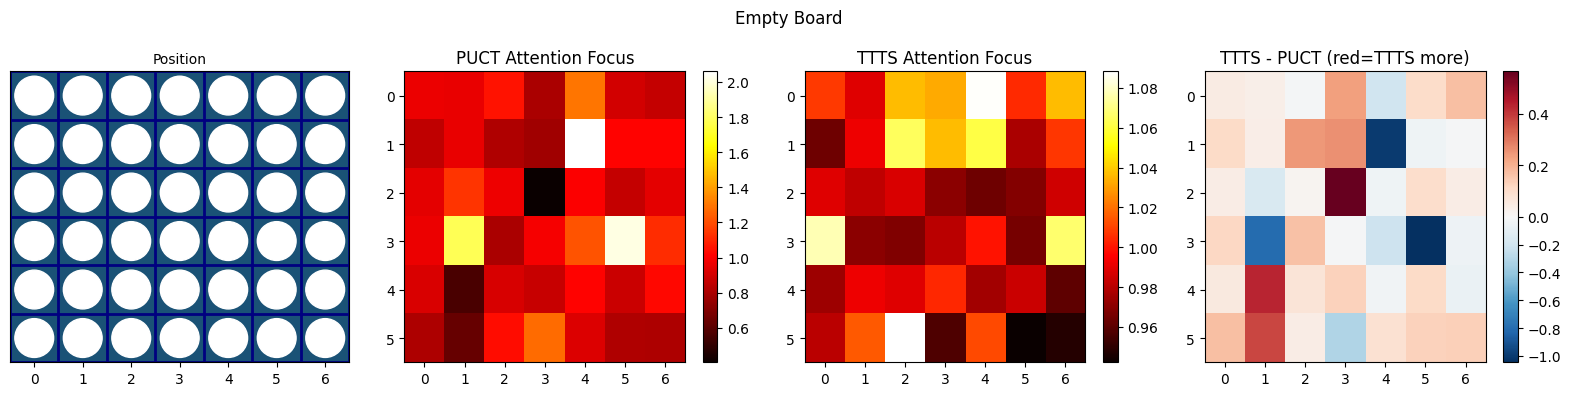

In [9]:
def visualize_attention_comparison(state, title=""):
    """Compare attention patterns between models."""
    puct_attn = puct_extractor.get_attention(state)
    ttts_attn = ttts_extractor.get_attention(state)
    
    n_layers = len(puct_attn)
    
    # Average across heads and take last layer
    puct_last = puct_attn[-1].squeeze(0).mean(dim=0).numpy()  # (42, 42)
    ttts_last = ttts_attn[-1].squeeze(0).mean(dim=0).numpy()
    
    # Reshape to board
    # Each row shows what position i attends to
    # Sum columns to get "how much attention each position receives"
    puct_received = puct_last.sum(axis=0).reshape(6, 7)
    ttts_received = ttts_last.sum(axis=0).reshape(6, 7)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # Board state
    render_board_matplotlib(state, axes[0], 'Position')
    
    # PUCT attention
    im1 = axes[1].imshow(puct_received, cmap='hot', aspect='auto')
    axes[1].set_title('PUCT Attention Focus')
    axes[1].set_xticks(range(7))
    axes[1].set_yticks(range(6))
    plt.colorbar(im1, ax=axes[1])
    
    # TTTS attention
    im2 = axes[2].imshow(ttts_received, cmap='hot', aspect='auto')
    axes[2].set_title('TTTS Attention Focus')
    axes[2].set_xticks(range(7))
    axes[2].set_yticks(range(6))
    plt.colorbar(im2, ax=axes[2])
    
    # Difference
    diff = ttts_received - puct_received
    norm = TwoSlopeNorm(vmin=diff.min(), vcenter=0, vmax=diff.max())
    im3 = axes[3].imshow(diff, cmap='RdBu_r', norm=norm, aspect='auto')
    axes[3].set_title('TTTS - PUCT (red=TTTS more)')
    axes[3].set_xticks(range(7))
    axes[3].set_yticks(range(6))
    plt.colorbar(im3, ax=axes[3])
    
    if title:
        fig.suptitle(title, fontsize=12)
    
    plt.tight_layout()
    plt.show()

# Visualize on empty board
visualize_attention_comparison(game.initial_state(), "Empty Board")

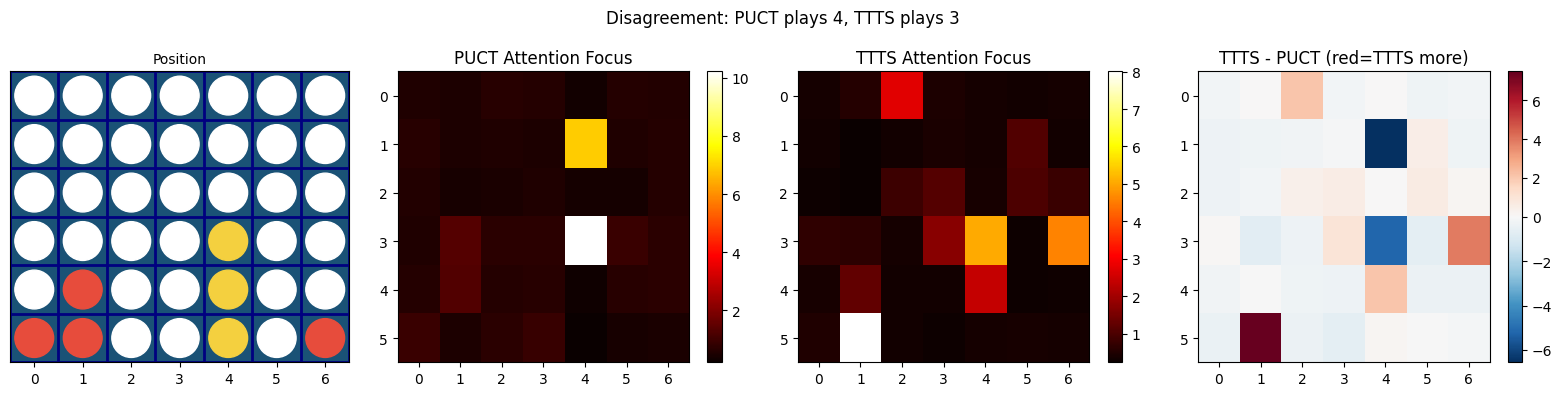

In [10]:
# Visualize on a position where they disagree
if move_disagreements:
    d = move_disagreements[0]
    visualize_attention_comparison(
        d['state'], 
        f"Disagreement: PUCT plays {d['puct_move']}, TTTS plays {d['ttts_move']}"
    )

## 4. Tactical Pattern Recognition

Can each model recognize critical tactical patterns? Let's test them on specific positions.

In [11]:
def create_position(moves):
    """Create a position by playing a sequence of column moves."""
    state = game.initial_state()
    for col in moves:
        state = game.next_state(state, col)
    return state

def test_tactical_position(state, correct_move, description):
    """Test if models find the correct tactical move."""
    print(f"\n{description}")
    print(f"Correct move: column {correct_move}")
    print(game.display(state))
    
    puct_p, puct_v = get_policy_and_value(puct_model, state)
    ttts_p, ttts_v = get_policy_and_value(ttts_model, state)
    
    puct_move = np.argmax(puct_p)
    ttts_move = np.argmax(ttts_p)
    
    puct_correct = puct_move == correct_move
    ttts_correct = ttts_move == correct_move
    
    print(f"\nPUCT: plays {puct_move} (prob={puct_p[puct_move]:.2f}, correct_prob={puct_p[correct_move]:.2f}) {'OK' if puct_correct else 'MISS'}")
    print(f"TTTS: plays {ttts_move} (prob={ttts_p[ttts_move]:.2f}, correct_prob={ttts_p[correct_move]:.2f}) {'OK' if ttts_correct else 'MISS'}")
    
    return puct_correct, ttts_correct

# Test cases
tactical_tests = [
    # Win in 1: Three in a row, complete it
    ([3, 0, 3, 1, 3], 3, "Win in 1: Complete vertical four"),
    
    # Block opponent's win
    ([3, 3, 4, 4, 5], 5, "Block: Stop horizontal four"),
    
    # Create winning threat
    ([3, 0, 4, 1], 2, "Threat: Create double threat with column 2 or 5"),
]

results = []
for moves, correct, desc in tactical_tests:
    try:
        state = create_position(moves)
        puct_ok, ttts_ok = test_tactical_position(state, correct, desc)
        results.append((desc, puct_ok, ttts_ok))
    except Exception as e:
        print(f"Error in {desc}: {e}")


Win in 1: Complete vertical four
Correct move: column 3
0 1 2 3 4 5 6 
. . . . . . . 
. . . . . . . 
. . . . . . . 
. . . X . . . 
. . . X . . . 
O O . X . . . 


PUCT: plays 3 (prob=0.25, correct_prob=0.25) OK
TTTS: plays 3 (prob=0.18, correct_prob=0.18) OK

Block: Stop horizontal four
Correct move: column 5
0 1 2 3 4 5 6 
. . . . . . . 
. . . . . . . 
. . . . . . . 
. . . . . . . 
. . . O O . . 
. . . X X X . 


PUCT: plays 3 (prob=0.20, correct_prob=0.17) MISS
TTTS: plays 2 (prob=0.29, correct_prob=0.13) MISS

Threat: Create double threat with column 2 or 5
Correct move: column 2
0 1 2 3 4 5 6 
. . . . . . . 
. . . . . . . 
. . . . . . . 
. . . . . . . 
. . . . . . . 
O O . X X . . 


PUCT: plays 0 (prob=0.26, correct_prob=0.01) MISS
TTTS: plays 3 (prob=0.16, correct_prob=0.16) MISS


In [12]:
# Summary of tactical tests
if results:
    print("\n" + "="*50)
    print("TACTICAL TEST SUMMARY")
    print("="*50)
    
    puct_score = sum(1 for _, p, _ in results if p)
    ttts_score = sum(1 for _, _, t in results if t)
    
    print(f"\nPUCT: {puct_score}/{len(results)} correct")
    print(f"TTTS: {ttts_score}/{len(results)} correct")


TACTICAL TEST SUMMARY

PUCT: 1/3 correct
TTTS: 1/3 correct


## 5. Confidence Calibration

When a model says a position has value 0.7, does it actually win ~70% of the time? Let's test calibration.

In [13]:
def play_out_position(state, model, n_rollouts=20):
    """Play position to completion with model's greedy policy, return win rate."""
    wins = 0
    starting_player = game.current_player(state)
    
    for _ in range(n_rollouts):
        s = state.copy()
        move_count = 0
        
        while not game.is_terminal(s) and move_count < 50:
            policy, _ = get_policy_and_value(model, s)
            
            # Add small noise to break ties and add variety
            policy = policy + np.random.uniform(0, 0.01, size=policy.shape)
            
            # Mask illegal moves
            legal_mask = game.legal_actions_mask(s)
            policy = policy * legal_mask
            if policy.sum() > 0:
                policy = policy / policy.sum()
                action = np.random.choice(len(policy), p=policy)
            else:
                action = np.random.choice(game.legal_actions(s))
            
            s = game.next_state(s, action)
            move_count += 1
        
        if game.is_terminal(s):
            reward = game.terminal_reward(s)
            final_player = game.current_player(s)
            
            if final_player == starting_player:
                result = reward
            else:
                result = -reward
            
            if result > 0:
                wins += 1
            elif result == 0:
                wins += 0.5  # Draw counts as half
    
    return wins / n_rollouts

# Collect calibration data
print("Collecting calibration data (this takes a minute)...")

calibration_data = {'puct': [], 'ttts': []}

# Sample random positions
np.random.seed(42)
for i in range(50):
    # Random game to random position
    state = game.initial_state()
    n_moves = np.random.randint(5, 25)
    
    for _ in range(n_moves):
        if game.is_terminal(state):
            break
        legal = game.legal_actions(state)
        state = game.next_state(state, np.random.choice(legal))
    
    if game.is_terminal(state):
        continue
    
    # Get predictions
    _, puct_v = get_policy_and_value(puct_model, state)
    _, ttts_v = get_policy_and_value(ttts_model, state)
    
    # Play out with each model
    puct_actual = play_out_position(state, puct_model, n_rollouts=10)
    ttts_actual = play_out_position(state, ttts_model, n_rollouts=10)
    
    # Convert value [-1, 1] to win prob [0, 1]
    puct_pred = (puct_v + 1) / 2
    ttts_pred = (ttts_v + 1) / 2
    
    calibration_data['puct'].append((puct_pred, puct_actual))
    calibration_data['ttts'].append((ttts_pred, ttts_actual))
    
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/50 positions evaluated")

print("Done!")

  10/50 positions evaluated
  20/50 positions evaluated
  30/50 positions evaluated
  40/50 positions evaluated
  50/50 positions evaluated
Done!


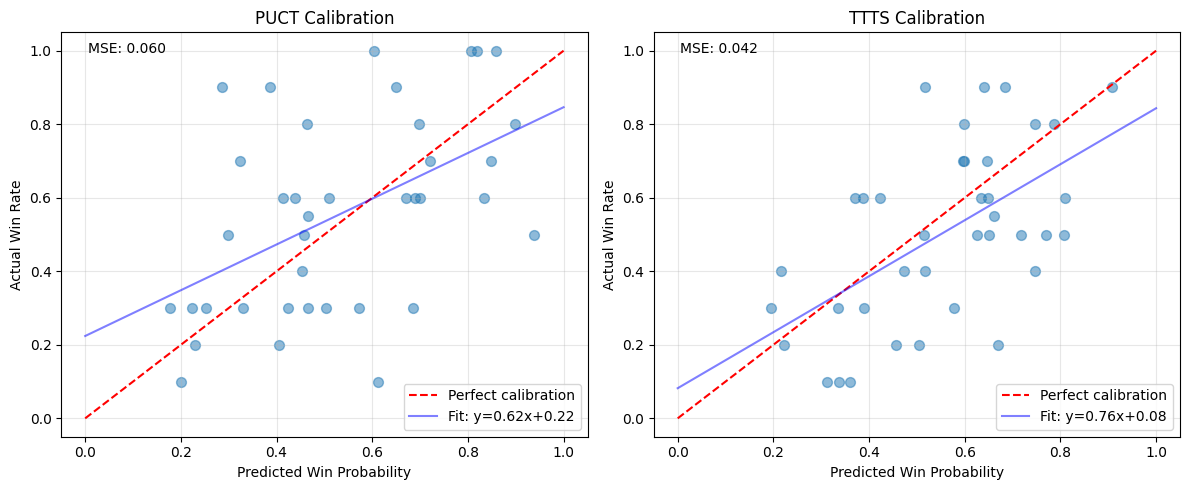

In [14]:
# Plot calibration curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (name, data) in enumerate([('PUCT', calibration_data['puct']), ('TTTS', calibration_data['ttts'])]):
    predictions = [d[0] for d in data]
    actuals = [d[1] for d in data]
    
    ax = axes[idx]
    ax.scatter(predictions, actuals, alpha=0.5, s=50)
    ax.plot([0, 1], [0, 1], 'r--', label='Perfect calibration')
    
    # Fit line
    if len(predictions) > 2:
        z = np.polyfit(predictions, actuals, 1)
        p = np.poly1d(z)
        x_line = np.linspace(0, 1, 100)
        ax.plot(x_line, p(x_line), 'b-', alpha=0.5, label=f'Fit: y={z[0]:.2f}x+{z[1]:.2f}')
    
    ax.set_xlabel('Predicted Win Probability')
    ax.set_ylabel('Actual Win Rate')
    ax.set_title(f'{name} Calibration')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Calculate calibration error
    mse = np.mean([(p - a)**2 for p, a in zip(predictions, actuals)])
    ax.text(0.05, 0.95, f'MSE: {mse:.3f}', transform=ax.transAxes, fontsize=10)

plt.tight_layout()
plt.show()

## 6. Embedding Space Visualization

How do the models internally represent board positions? Let's visualize the embedding space.

In [15]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

def get_embedding(model, state):
    """Get the pooled embedding for a position."""
    canonical = game.canonical_state(state)
    state_tensor = game.to_tensor(canonical).unsqueeze(0).to(device)
    
    with torch.no_grad():
        # Get embeddings before the heads
        B, T = state_tensor.shape
        pos = torch.arange(T, device=device)
        x = model.tok_emb(state_tensor) + model.pos_emb(pos)
        
        for block in model.blocks:
            x = block(x)
        
        x = model.norm(x)
        pooled = x.mean(dim=1)  # (1, n_embd)
        
    return pooled.squeeze().cpu().numpy()

# Collect embeddings from various positions
print("Collecting embeddings...")

positions = []
puct_embeddings = []
ttts_embeddings = []
labels = []  # For coloring: early/mid/late game

np.random.seed(123)
for _ in range(100):
    state = game.initial_state()
    n_moves = np.random.randint(0, 30)
    
    for move_num in range(n_moves):
        if game.is_terminal(state):
            break
        legal = game.legal_actions(state)
        state = game.next_state(state, np.random.choice(legal))
    
    if not game.is_terminal(state):
        positions.append(state.copy())
        puct_embeddings.append(get_embedding(puct_model, state))
        ttts_embeddings.append(get_embedding(ttts_model, state))
        
        # Label by game phase
        piece_count = np.sum(state != 0)
        if piece_count < 8:
            labels.append('early')
        elif piece_count < 20:
            labels.append('mid')
        else:
            labels.append('late')

puct_embeddings = np.array(puct_embeddings)
ttts_embeddings = np.array(ttts_embeddings)

print(f"Collected {len(positions)} positions")
print(f"Embedding dim: {puct_embeddings.shape[1]}")

Collected 66 positions
Embedding dim: 256


/Users/calaldred/Code/nanozero/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/calaldred/Code/nanozero/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/calaldred/Code/nanozero/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/calaldred/Code/nanozero/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/calaldred/Code/nanozero/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/calaldred/Code/nanozero/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encounter

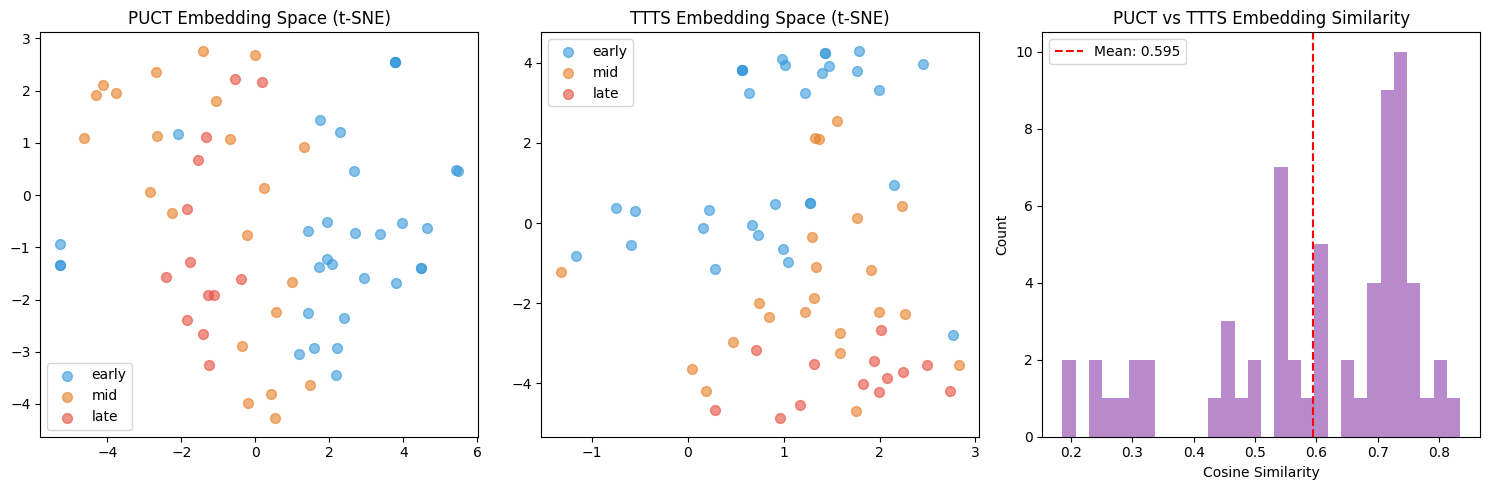

In [16]:
# Reduce dimensionality and visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# t-SNE for PUCT
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(positions)-1))
puct_2d = tsne.fit_transform(puct_embeddings)

colors = {'early': '#3498DB', 'mid': '#E67E22', 'late': '#E74C3C'}
for label in ['early', 'mid', 'late']:
    mask = [l == label for l in labels]
    axes[0].scatter(puct_2d[mask, 0], puct_2d[mask, 1], 
                    c=colors[label], label=label, alpha=0.6, s=50)
axes[0].set_title('PUCT Embedding Space (t-SNE)')
axes[0].legend()

# t-SNE for TTTS
ttts_2d = tsne.fit_transform(ttts_embeddings)
for label in ['early', 'mid', 'late']:
    mask = [l == label for l in labels]
    axes[1].scatter(ttts_2d[mask, 0], ttts_2d[mask, 1], 
                    c=colors[label], label=label, alpha=0.6, s=50)
axes[1].set_title('TTTS Embedding Space (t-SNE)')
axes[1].legend()

# Compare: how similar are embeddings between models?
# Compute cosine similarity for each position
similarities = []
for p_emb, t_emb in zip(puct_embeddings, ttts_embeddings):
    cos_sim = np.dot(p_emb, t_emb) / (np.linalg.norm(p_emb) * np.linalg.norm(t_emb))
    similarities.append(cos_sim)

axes[2].hist(similarities, bins=30, color='#9B59B6', alpha=0.7)
axes[2].axvline(np.mean(similarities), color='red', linestyle='--', 
                label=f'Mean: {np.mean(similarities):.3f}')
axes[2].set_xlabel('Cosine Similarity')
axes[2].set_ylabel('Count')
axes[2].set_title('PUCT vs TTTS Embedding Similarity')
axes[2].legend()

plt.tight_layout()
plt.show()

## 7. Policy Entropy Over Game Phases

Does one model become more decisive as the game progresses?

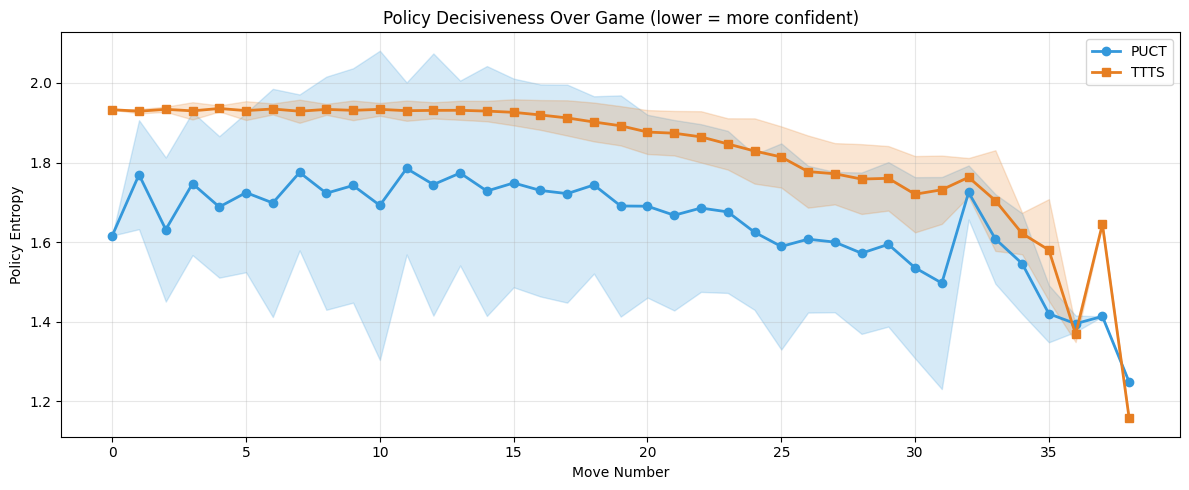

In [17]:
def entropy(p):
    p = p[p > 1e-8]
    return -np.sum(p * np.log(p))

# Collect entropy data by move number
entropy_by_move = {'puct': defaultdict(list), 'ttts': defaultdict(list)}

np.random.seed(456)
for _ in range(100):
    state = game.initial_state()
    
    for move_num in range(40):
        if game.is_terminal(state):
            break
        
        puct_p, _ = get_policy_and_value(puct_model, state)
        ttts_p, _ = get_policy_and_value(ttts_model, state)
        
        entropy_by_move['puct'][move_num].append(entropy(puct_p))
        entropy_by_move['ttts'][move_num].append(entropy(ttts_p))
        
        # Random move
        legal = game.legal_actions(state)
        state = game.next_state(state, np.random.choice(legal))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

moves = sorted(entropy_by_move['puct'].keys())
puct_means = [np.mean(entropy_by_move['puct'][m]) for m in moves]
puct_stds = [np.std(entropy_by_move['puct'][m]) for m in moves]
ttts_means = [np.mean(entropy_by_move['ttts'][m]) for m in moves]
ttts_stds = [np.std(entropy_by_move['ttts'][m]) for m in moves]

ax.plot(moves, puct_means, 'o-', label='PUCT', color='#3498DB', linewidth=2)
ax.fill_between(moves, 
                [m-s for m,s in zip(puct_means, puct_stds)],
                [m+s for m,s in zip(puct_means, puct_stds)],
                alpha=0.2, color='#3498DB')

ax.plot(moves, ttts_means, 's-', label='TTTS', color='#E67E22', linewidth=2)
ax.fill_between(moves,
                [m-s for m,s in zip(ttts_means, ttts_stds)],
                [m+s for m,s in zip(ttts_means, ttts_stds)],
                alpha=0.2, color='#E67E22')

ax.set_xlabel('Move Number')
ax.set_ylabel('Policy Entropy')
ax.set_title('Policy Decisiveness Over Game (lower = more confident)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Cleanup

In [ ]:
# Remove hooks
puct_extractor.remove_hooks()
ttts_extractor.remove_hooks()
print("Hooks removed. Exploration complete!")

## Summary

This notebook explored several dimensions of model comparison:

1. **Opening Personality** - Do models prefer different starting moves?
2. **Policy Disagreement** - Where and when do they disagree most?
3. **Attention Patterns** - What parts of the board do they focus on?
4. **Tactical Recognition** - Can they spot winning moves and threats?
5. **Calibration** - Are their confidence estimates accurate?
6. **Embedding Space** - Do they represent positions similarly internally?
7. **Entropy Dynamics** - Which is more decisive at different game stages?

These analyses reveal *how* PUCT and TTTS training produce models with different "personalities" beyond just win rates.